In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#reading the data file from github reppo
url = "https://raw.githubusercontent.com/Ilumiles/Pizza_Place_Sales/main/pizza_sales/order_details.csv"
#storing the data one after the other in a varibale
order_details = pd.read_csv(url) 
order_details.sample(5)

,order_details_id,order_id,pizza_id,quantity
36364,36365,16055,peppr_salami_s,1
21414,21415,9396,big_meat_s,1
48475,48476,21288,spinach_fet_s,1
5431,5432,2399,mexicana_m,1
47481,47482,20863,ckn_pesto_s,1


In [4]:
#reading the data for the order locally 
order =pd.read_csv(r"C:\Users\aoilu\Documents\Data Science Techcrush\Pizza+Place+Sales\pizza_sales\orders.csv")

order.head(5)

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [5]:
#reading the data for the order locally 
pizza_types =pd.read_csv(r"C:\Users\aoilu\Documents\Data Science Techcrush\Pizza+Place+Sales\pizza_sales\pizza_types.csv", encoding="cp1252")

pizza_types.head(5)

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [6]:
#reading the data for the order locally 
pizza =pd.read_csv(r"C:\Users\aoilu\Documents\Data Science Techcrush\Pizza+Place+Sales\pizza_sales\pizzas.csv")

pizza.head(5)

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [7]:
#merge data
#the order and order details have order_id as a unique identifier to create a pf1

In [8]:
df1 = pd.merge(order, order_details, on = 'order_id', how = 'outer') #merging the order and order-pizaa folder together

df1.tail(5)

,order_id,date,time,order_details_id,pizza_id,quantity
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1
48619,21350,2015-12-31,23:02:05,48620,bbq_ckn_s,1


In [9]:
#the pizza and pizza types have pizza_type_id as a unique identifier 
df2 = pd.merge(pizza_types, pizza, on = 'pizza_type_id', how = 'outer')

df2.tail(5)

,pizza_type_id,name,category,ingredients,pizza_id,size,price
91,the_greek,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",the_greek_xl,XL,25.50
92,the_greek,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",the_greek_xxl,XXL,35.95
93,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",veggie_veg_s,S,12.00
94,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",veggie_veg_m,M,16.00
95,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",veggie_veg_l,L,20.25


In [10]:
#merge all into one dataframe on pizza_id
df = pd.merge(df1, df2, on="pizza_id", how ="outer")


df.head(5)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price
0,11.0,2015-01-01,13:02:59,26.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75
1,17.0,2015-01-01,13:53:00,43.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75
2,27.0,2015-01-01,15:11:17,71.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75
3,33.0,2015-01-01,15:54:08,83.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75
4,51.0,2015-01-01,18:48:28,123.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75


In [11]:
#have an overview what the number of role and columns
df.shape

(48625, 12)

In [12]:
df.tail(5)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price
48620,21251.0,2015-12-30,12:45:20,48406.0,veggie_veg_s,2.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0
48621,21296.0,2015-12-31,15:13:40,48493.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0
48622,21298.0,2015-12-31,15:35:37,48500.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0
48623,21299.0,2015-12-31,15:52:16,48503.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0
48624,21319.0,2015-12-31,18:07:19,48553.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0


In [13]:
#check the missing values and the variable type for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48625 entries, 0 to 48624
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  float64
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  float64
 4   pizza_id          48625 non-null  object 
 5   quantity          48620 non-null  float64
 6   pizza_type_id     48625 non-null  object 
 7   name              48625 non-null  object 
 8   category          48625 non-null  object 
 9   ingredients       48625 non-null  object 
 10  size              48625 non-null  object 
 11  price             48625 non-null  float64
dtypes: float64(4), object(8)
memory usage: 4.5+ MB


In [14]:
#check the total sum of missing values in each column
df.isna().sum()

order_id            5
date                5
time                5
order_details_id    5
pizza_id            0
quantity            5
pizza_type_id       0
name                0
category            0
ingredients         0
size                0
price               0
dtype: int64

In [ ]:
#checking roles with missing column and roles. 
df[df["order_id"].isna()]

#with the missing data, we can not guess or predict or fill the data. the order id is missing, its advisable we drop them

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price
2372,NaN,NaN,NaN,NaN,big_meat_l,NaN,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau...",L,20.50
2373,NaN,NaN,NaN,NaN,big_meat_m,NaN,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau...",M,16.00
13610,NaN,NaN,NaN,NaN,five_cheese_m,NaN,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",M,15.50
13611,NaN,NaN,NaN,NaN,five_cheese_s,NaN,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",S,12.50
15462,NaN,NaN,NaN,NaN,four_cheese_s,NaN,four_cheese,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",S,11.75


In [16]:
#since the number of rows in few (5), its better to delete them, order id, order_details_id are missing

In [17]:
df = df.dropna(subset=["order_id"])


In [ ]:
df.isna().sum()

#no more missing data

order_id            0
date                0
time                0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
name                0
category            0
ingredients         0
size                0
price               0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48620 entries, 0 to 48624
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  float64
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  float64
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  float64
 6   pizza_type_id     48620 non-null  object 
 7   name              48620 non-null  object 
 8   category          48620 non-null  object 
 9   ingredients       48620 non-null  object 
 10  size              48620 non-null  object 
 11  price             48620 non-null  float64
dtypes: float64(4), object(8)
memory usage: 4.8+ MB


In [20]:
df.sample(5)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price
30390,15496.0,2015-09-16,14:29:23,35100.0,pepperoni_s,1.0,pepperoni,The Pepperoni Pizza,Classic,"Mozzarella Cheese, Pepperoni",S,9.75
44306,14784.0,2015-09-04,18:35:17,33473.0,thai_ckn_l,1.0,thai_ckn,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",L,20.75
5006,2718.0,2015-02-14,22:16:39,6139.0,calabrese_m,1.0,calabrese,The Calabrese Pizza,Supreme,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,...",M,16.25
48018,15976.0,2015-09-26,19:40:10,36185.0,veggie_veg_m,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",M,16.00
38617,8391.0,2015-05-21,12:34:40,19097.0,spicy_ital_l,1.0,spicy_ital,The Spicy Italian Pizza,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",L,20.75


### 1.What is the total revenue/sales?

In [21]:
# the summation and total of price
df["revenue"] = df["quantity"] * df["price"]
total_revenue = df["revenue"].sum()

print("The total reveue/sales is $", total_revenue)



The total reveue/sales is $ 817860.05


## 2. What is the total quantity sold

In [22]:
total_quantity = df["quantity"].sum()
print("The total quantity sold: ",total_quantity)

The total quantity sold:  49574.0


## 3. Find the total order

In [23]:
total_orders = df["order_id"].nunique()
print("Total orders:", total_orders)

Total orders: 21350


## 4.	How many pizza types do they sell?

In [24]:
total_pizza_types = df["pizza_type_id"].nunique()
print("Total pizza types:", total_pizza_types)

Total pizza types: 32


## 5.	Find the average price of the pizzas.

In [25]:
average_price = df["price"].mean()
print(f"Average pizza price: ${average_price:.2f}")

Average pizza price: $16.49


In [26]:
df.sample(5)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price,revenue
8565,15254.0,2015-09-12,16:16:46,34558.0,ckn_alfredo_m,1.0,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",M,16.75,16.75
8171,2710.0,2015-02-14,20:00:00,6115.0,ckn_alfredo_m,1.0,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",M,16.75,16.75
25430,20542.0,2015-12-15,17:30:07,46785.0,mexicana_s,1.0,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",S,12.00,12.00
17084,15431.0,2015-09-15,15:28:17,34951.0,hawaiian_l,1.0,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",L,16.50,16.50
6661,3737.0,2015-03-04,18:27:40,8538.0,cali_ckn_m,2.0,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",M,16.75,33.50


## 6.	What are the peak hours of sales?

In [27]:
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.hour

hourly_sales = df.groupby("hour").size().reset_index(name="sales")

hourly_sales = hourly_sales.sort_values("sales", ascending=False)

hourly_sales = hourly_sales.reset_index(drop=True)

hourly_sales.head()

,hour,sales
0,12,6543
1,13,6203
2,18,5359
3,17,5143
4,19,4350


In [28]:
#highest ordering time

peak_hour = hourly_sales.loc[hourly_sales["sales"].idxmax(), "hour"] #finds the row index where sales is highest and retirieve the corresponding hour
print("The peak hour:", peak_hour)

The peak hour: 12


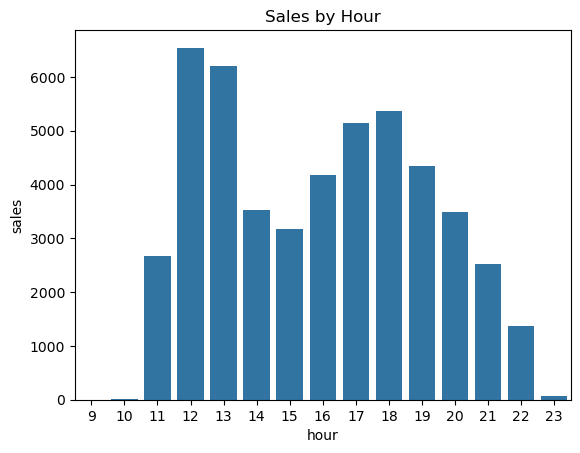

In [29]:
sns.barplot(data=hourly_sales, x="hour", y="sales")
plt.title("Sales by Hour")
plt.show()

## 7.	Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

In [30]:
df["date"] = pd.to_datetime(df["date"]) #convert the date column to datetime df

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48620 entries, 0 to 48624
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  float64       
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  object        
 3   order_details_id  48620 non-null  float64       
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  float64       
 6   pizza_type_id     48620 non-null  object        
 7   name              48620 non-null  object        
 8   category          48620 non-null  object        
 9   ingredients       48620 non-null  object        
 10  size              48620 non-null  object        
 11  price             48620 non-null  float64       
 12  revenue           48620 non-null  float64       
 13  hour              48620 non-null  int32         
dtypes: datetime64[ns](1), float

In [ ]:
#creating a column to store the day of the week
df["day_of_week"] = df["date"].dt.day_name()

In [33]:
df.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price,revenue,hour,day_of_week
0,11.0,2015-01-01,13:02:59,26.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,13,Thursday
1,17.0,2015-01-01,13:53:00,43.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,13,Thursday
2,27.0,2015-01-01,15:11:17,71.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,15,Thursday
3,33.0,2015-01-01,15:54:08,83.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,15,Thursday
4,51.0,2015-01-01,18:48:28,123.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,18,Thursday


In [34]:
sales_by_day = df.groupby("day_of_week")["revenue"].sum()
sales_by_day = sales_by_day.reset_index(name="revenue")
sales_by_day.head()

,day_of_week,revenue
0,Friday,136073.90
1,Monday,107329.55
2,Saturday,123182.40
3,Sunday,99203.50
4,Thursday,123528.50


In [35]:
highest_sales_day = sales_by_day.loc[sales_by_day["revenue"].idxmax(), "day_of_week"]
print("Highest sales day:", highest_sales_day)

Highest sales day: Friday


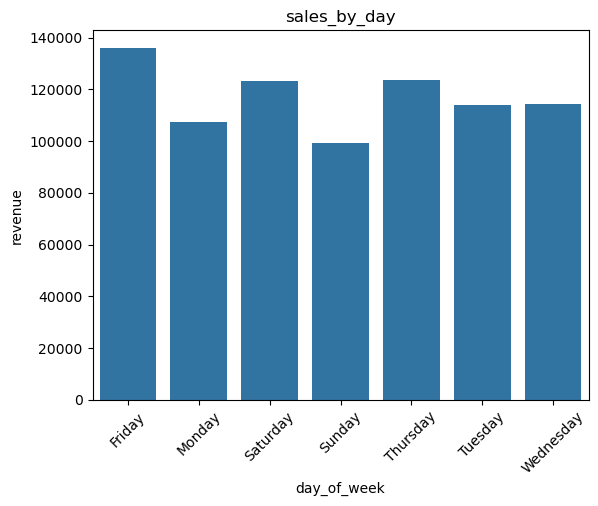

In [36]:
sns.barplot(data=sales_by_day, x="day_of_week", y="revenue")
plt.title("sales_by_day")
plt.xticks(rotation=45)
plt.show()

## 8.	Find the top 5 bestselling pizzas.

In [37]:
top_5_pizzas = df.groupby("name")["quantity"].sum().sort_values(ascending=False)

top_5_pizzas.head(5)

name
The Classic Deluxe Pizza      2453.0
The Barbecue Chicken Pizza    2432.0
The Hawaiian Pizza            2422.0
The Pepperoni Pizza           2418.0
The Thai Chicken Pizza        2371.0
Name: quantity, dtype: float64

## 9.	Find the sales made in each month. Any trend noticeable?

In [38]:
df["month_num"] = df["date"].dt.month
df["month"] = df["date"].dt.month_name()

In [39]:
df.tail()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price,revenue,hour,day_of_week,month_num,month
48620,21251.0,2015-12-30,12:45:20,48406.0,veggie_veg_s,2.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0,24.0,12,Wednesday,12,December
48621,21296.0,2015-12-31,15:13:40,48493.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0,12.0,15,Thursday,12,December
48622,21298.0,2015-12-31,15:35:37,48500.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0,12.0,15,Thursday,12,December
48623,21299.0,2015-12-31,15:52:16,48503.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0,12.0,15,Thursday,12,December
48624,21319.0,2015-12-31,18:07:19,48553.0,veggie_veg_s,1.0,veggie_veg,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper...",S,12.0,12.0,18,Thursday,12,December


In [40]:
sales_by_month = (df.groupby(["month_num", "month"])["revenue"].sum().reset_index().sort_values("month_num"))

In [41]:

sales_by_month.head(12)

,month_num,month,revenue
0,1,January,69793.30
1,2,February,65159.60
2,3,March,70397.10
3,4,April,68736.80
4,5,May,71402.75
5,6,June,68230.20
6,7,July,72557.90
7,8,August,68278.25
8,9,September,64180.05
9,10,October,64027.60


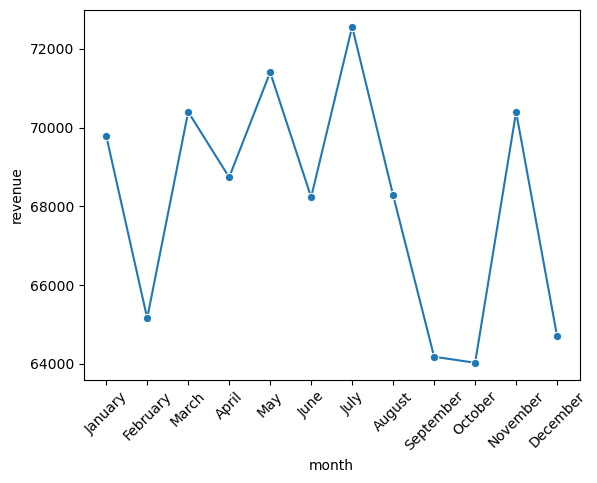

In [42]:
sns.lineplot(
    data=sales_by_month,
    x="month",
    y="revenue",
    marker="o"
)

plt.xticks(rotation=45)
plt.show()

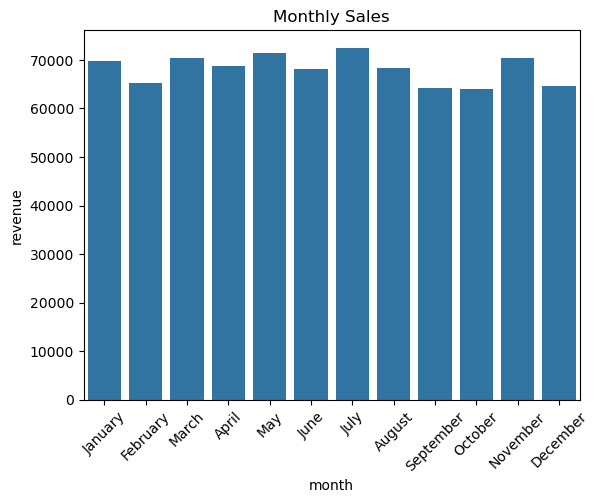

In [43]:
sns.barplot(
    data=sales_by_month,
    y="revenue",
    x="month"
)

plt.title("Monthly Sales")
plt.xticks(rotation=45)
plt.show()

In [44]:
sales_by_month.describe()

,month_num,revenue
count,12.000000,12.000000
mean,6.500000,68155.004167
std,3.605551,2965.868139
min,1.000000,64027.600000
25%,3.750000,65044.987500
50%,6.500000,68507.525000
75%,9.250000,70395.787500
max,12.000000,72557.900000


 Any trend noticeable? Monthly sales remain relatively stable across the year, with revenue fluctuating slightly between approximately 64K and 72K. There is no strong seasonal pattern, but minor increases are observed in higher months.

## 10.	Are there pizza types that are not doing well on the menu?

In [45]:
#Find total sales per pizza type

pizza_performance = (df.groupby("pizza_type_id")["quantity"].sum().sort_values(ascending=True))

print(pizza_performance.head(20))

pizza_type_id
brie_carre       490.0
mediterraneo     934.0
calabrese        937.0
spinach_supr     950.0
soppressata      961.0
spin_pesto       970.0
ckn_pesto        973.0
ital_veggie      981.0
ckn_alfredo      987.0
green_garden     997.0
pep_msh_pep     1359.0
five_cheese     1409.0
the_greek       1420.0
ital_cpcllo     1438.0
peppr_salami    1446.0
spinach_fet     1446.0
prsc_argla      1457.0
napolitana      1464.0
mexicana        1484.0
veggie_veg      1526.0
Name: quantity, dtype: float64


In [46]:
#Add revenue for better analysis

pizza_revenue = ( df.groupby("pizza_type_id")["revenue"].sum() .sort_values(ascending=True).reset_index(name="sales"))

print(pizza_revenue.head(20))

   pizza_type_id     sales
0     brie_carre  11588.50
1   green_garden  13955.75
2   spinach_supr  15277.75
3   mediterraneo  15360.50
4     spin_pesto  15596.00
5      calabrese  15934.25
6    ital_veggie  16019.25
7    soppressata  16425.75
8      ckn_pesto  16701.75
9    ckn_alfredo  16900.25
10   pep_msh_pep  18834.50
11      big_meat  22968.00
12   spinach_fet  23271.25
13    napolitana  24087.00
14    prsc_argla  24193.25
15    veggie_veg  24374.75
16   ital_cpcllo  25094.00
17  peppr_salami  25529.00
18   five_cheese  26066.50
19      mexicana  26780.75


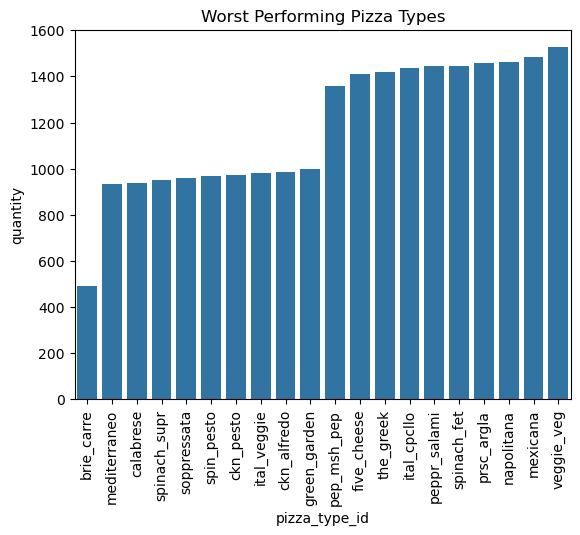

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

worst_pizzas = pizza_performance.head(20).reset_index()

sns.barplot(data=worst_pizzas, y="quantity",  x="pizza_type_id")

plt.title("Worst Performing Pizza Types")
plt.xticks(rotation=90)
plt.show()

In [48]:
avg_sales = df.groupby("pizza_type_id")["quantity"].sum().mean()

low_performers = pizza_performance[pizza_performance < avg_sales].reset_index(name="sales")
print(low_performers)

   pizza_type_id   sales
0     brie_carre   490.0
1   mediterraneo   934.0
2      calabrese   937.0
3   spinach_supr   950.0
4    soppressata   961.0
5     spin_pesto   970.0
6      ckn_pesto   973.0
7    ital_veggie   981.0
8    ckn_alfredo   987.0
9   green_garden   997.0
10   pep_msh_pep  1359.0
11   five_cheese  1409.0
12     the_greek  1420.0
13   ital_cpcllo  1438.0
14  peppr_salami  1446.0
15   spinach_fet  1446.0
16    prsc_argla  1457.0
17    napolitana  1464.0
18      mexicana  1484.0
19    veggie_veg  1526.0


 the low performace are the Pizza_type below the average sales

In [49]:
#lets check the most ordered pizza size

df.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,name,category,ingredients,size,price,revenue,hour,day_of_week,month_num,month
0,11.0,2015-01-01,13:02:59,26.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,13,Thursday,1,January
1,17.0,2015-01-01,13:53:00,43.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,13,Thursday,1,January
2,27.0,2015-01-01,15:11:17,71.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,15,Thursday,1,January
3,33.0,2015-01-01,15:54:08,83.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,15,Thursday,1,January
4,51.0,2015-01-01,18:48:28,123.0,bbq_ckn_l,1.0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",L,20.75,20.75,18,Thursday,1,January


In [53]:
df["size"].value_counts()

size
L      18526
M      15385
S      14137
XL       544
XXL       28
Name: count, dtype: int64

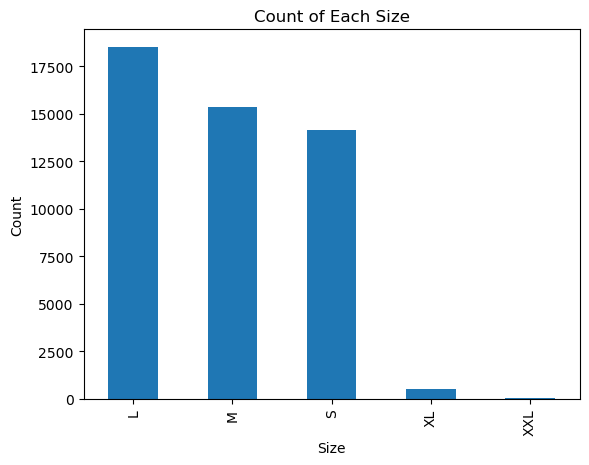

In [54]:
import matplotlib.pyplot as plt

df["size"].value_counts().plot(kind="bar")

plt.title("Count of Each Size")
plt.xlabel("Size")
plt.ylabel("Count")
plt.show()

In [61]:
#count the most used ingredients

ingredients_df = (df["ingredients"] .str.split(",") .explode()  .str.strip() .to_frame(name="ingredient"))

ingredients_df.head(5)
                    

,ingredient
0,Barbecued Chicken
0,Red Peppers
0,Green Peppers
0,Tomatoes
0,Red Onions


In [63]:
ingredient_counts =  ingredients_df["ingredient"] .value_counts() .reset_index()

ingredient_counts.columns = ["ingredient", "count"]

ingredient_counts.head(10)

,ingredient,count
0,Garlic,27422
1,Tomatoes,26601
2,Red Onions,19547
3,Red Peppers,16284
4,Mozzarella Cheese,10333
5,Pepperoni,10300
6,Spinach,10012
7,Mushrooms,9624
8,Chicken,8443
9,Capocollo,6572


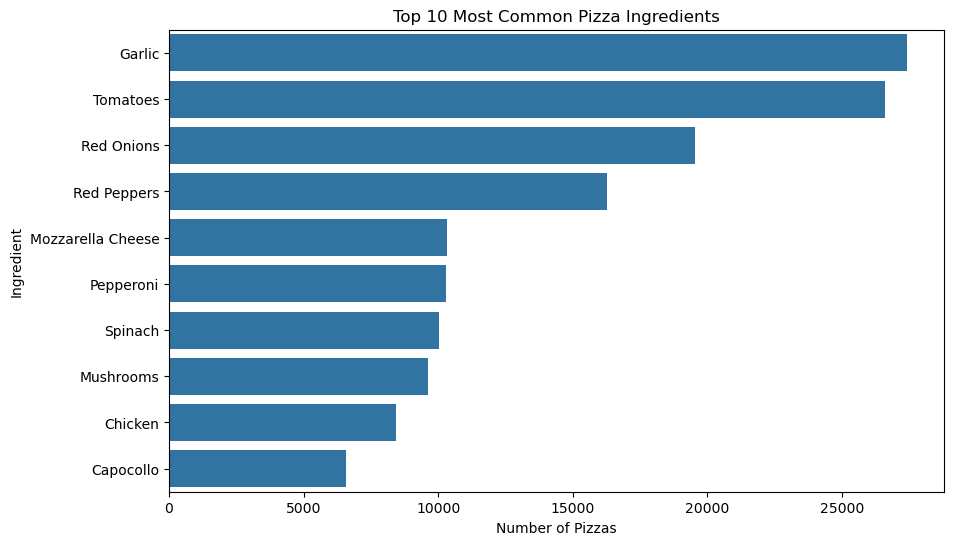

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = ingredient_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="count",
    y="ingredient"
)

plt.title("Top 10 Most Common Pizza Ingredients")
plt.xlabel("Number of Pizzas")
plt.ylabel("Ingredient")

plt.show()